|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Weight inits and investigations<h1>|
|<h2>Lecture:</h2>|<h1><b>Freezing weights during learning<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import time

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [2]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)

print(labels.shape)
print(data.shape)

(60000,)
(60000, 784)


In [3]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm ).float()
labelsT = torch.tensor( labels ).long()

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

# Create the DL model

In [28]:
# create a class for the model
def createTheMNISTNet(seed=None):

  class mnistNet(nn.Module):
    def __init__(self, seed=None):
      super().__init__()
      
      if isinstance(seed, (int, float)):
        torch.manual_seed(int(seed))

      ### input layer
      self.input = nn.Linear(784,64)

      ### hidden layer
      self.fc1 = nn.Linear(64,32)
      self.fc2 = nn.Linear(32,32)

      ### output layer
      self.output = nn.Linear(32,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.input(x) )
      x = F.relu( self.fc1(x) )
      x = F.relu( self.fc2(x) )
      return self.output(x)
    
    @torch.no_grad()
    def accuracy(self, yHat: torch.Tensor, y: torch.Tensor) -> float:
      return 100*torch.mean((torch.argmax(yHat, axis=1) == y).float()).detach().item()

  # create the model instance
  net = mnistNet(seed=seed)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer (using SGD to slow down learning!)
  optimizer = torch.optim.SGD(net.parameters(),lr=.001)

  return net,lossfun,optimizer

# Brief inspection of requires_grad

In [5]:
# inspect the "learning toggle" of a layer
N = createTheMNISTNet()[0]
print(N.fc1.weight.requires_grad)

X, y = next(iter(test_loader))
yHat = N(X)
print(yHat.shape, y.shape)
print(N.accuracy(yHat, y))

True
torch.Size([6000, 10]) torch.Size([6000])
10.849999636411667


In [6]:
N = createTheMNISTNet()[0]

# switch off all layers except input
for p in N.named_parameters():
  if 'input' not in p[0]:
    p[1].requires_grad = False

# check what we've done
for p in N.named_parameters():
  print('Requires_grad status in layer %s: %s' %(p[0],p[1].requires_grad))

Requires_grad status in layer input.weight: True
Requires_grad status in layer input.bias: True
Requires_grad status in layer fc1.weight: False
Requires_grad status in layer fc1.bias: False
Requires_grad status in layer fc2.weight: False
Requires_grad status in layer fc2.bias: False
Requires_grad status in layer output.weight: False
Requires_grad status in layer output.bias: False


# Create a function that trains the model

In [7]:
def function2trainTheModel(net,lossfun,optimizer):

  # number of epochs
  numepochs = 100

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):

    # NEW: switch off learning in all-but-output layers during first 1/2 of training
    if epochi<(numepochs/2):
      for p in net.named_parameters():
        if 'output' not in p[0]:
          p[1].requires_grad = False
    else:
      for p in net.named_parameters():
        p[1].requires_grad = True

    # loop over training data batches
    net.train()
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      batchAcc.append( net.accuracy(yHat, y) )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( net.accuracy(yHat, y) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,net

# Let's see it in action!

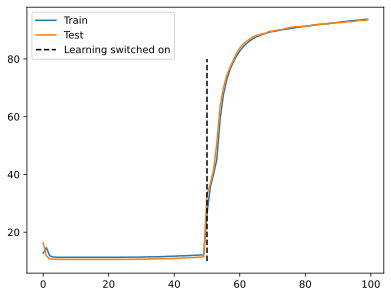

In [8]:
# create the network
net,lossfun,optimizer = createTheMNISTNet()

# train the model
trainAcc,testAcc,losses,net = function2trainTheModel(net,lossfun,optimizer)

plt.plot(trainAcc,label='Train')
plt.plot(testAcc,label='Test')
plt.plot([len(trainAcc)/2, len(trainAcc)/2],[10,80],'k--',label='Learning switched on')
plt.legend()
plt.show()

# Additional explorations

In [9]:
# 1) Switch off all the weights, but leave all the biases switched on. Can the model still learn (at least, better than
#    chance level)? Then do the opposite: let the weights learn but turn off learnign in the biases. How does the model
#    perform now, and what does this tell you about weights vs. biases?
#
# 2) Freeze only one layer, e.g., layer fc1 (freeze both the weights and biases). Store the accuracy output as a separate
#    variable, so you run the network again without freezing anything. Then plot the accuracies (with and without
#    freezing) on the same graph. How important is fc1 based on this plot?
#

In [ ]:
# 1) Switch off all the weights, but leave all the biases switched on. Can the model still learn (at least, better than
#    chance level)? Then do the opposite: let the weights learn but turn off learnign in the biases. How does the model
#    perform now, and what does this tell you about weights vs. biases?
# Answer:
# 1. weights frozen, biases learning: the model performs at chance level wit haccuracy around 11% (chance accuracy is 10% for 10 number classes in MNIST)
# 2. weights learning, biases frozen: the model learns well enough (~90% accuracy after 100 epochs)
# 3. weights are more important than biases for learning (obvious conclusion)

In [11]:
def trainTheModel(net,lossfun,optimizer,numepochs:int=100):

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      batchAcc.append( net.accuracy(yHat, y) )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)

    # compare the following really long line of code to the training accuracy lines
    testAcc.append( net.accuracy(yHat, y) )
  # end epochs

  # function output
  return trainAcc,testAcc,losses,net

In [18]:
# create the network
net,lossfun,optimizer = createTheMNISTNet()

# Switch off all the weights, but leave biases on:
for p in net.named_parameters():
  if 'weight' in p[0]:
    p[1].requires_grad = False

# train the model
numepochs = 100
trainAcc,testAcc,losses,net = trainTheModel(net,lossfun,optimizer,numepochs=numepochs)

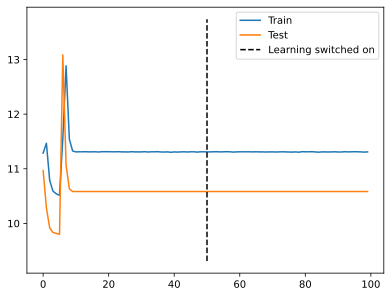

In [19]:
fig = plt.figure()
plt.plot(trainAcc,label='Train')
plt.plot(testAcc,label='Test')
plt.plot([len(trainAcc)/2, len(trainAcc)/2],[0.95*np.min([trainAcc, testAcc]),1.05*np.max([trainAcc, testAcc])],'k--',label='Learning switched on')
plt.legend()
plt.show()

In [20]:
# create the network
net,lossfun,optimizer = createTheMNISTNet()

# Switch off all the biases, but leave weights on:
for p in net.named_parameters():
  if 'bias' in p[0]:
    p[1].requires_grad = False

# train the model
numepochs = 100
trainAcc,testAcc,losses,net = trainTheModel(net,lossfun,optimizer,numepochs=numepochs)

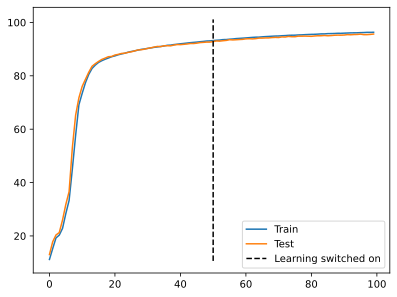

In [21]:
fig = plt.figure()
plt.plot(trainAcc,label='Train')
plt.plot(testAcc,label='Test')
plt.plot([len(trainAcc)/2, len(trainAcc)/2],[0.95*np.min([trainAcc, testAcc]),1.05*np.max([trainAcc, testAcc])],'k--',label='Learning switched on')
plt.legend()
plt.show()

In [ ]:
# 2) Freeze only one layer, e.g., layer fc1 (freeze both the weights and biases). Store the accuracy output as a separate
#    variable, so you run the network again without freezing anything. Then plot the accuracies (with and without
#    freezing) on the same graph. How important is fc1 based on this plot?
# Answer: Accuracies for fc1 with and without freezing are very similar, indicating that fc1 is not a critical layer for learning in this network architecture.

In [41]:
# create the network
seed = 41
net_freeze_fc1,lossfun_freeze_fc1,optimizer_freeze_fc1 = createTheMNISTNet(seed=seed)
net_no_freeze_fc1,lossfun_no_freeze_fc1,optimizer_no_freeze_fc1 = createTheMNISTNet(seed=seed)

assert torch.sum(net_freeze_fc1.fc1.weight.data.flatten().detach() - net_no_freeze_fc1.fc1.weight.data.flatten().detach()).item() == 0.0

# Freeze only layer fc1 (weights and biases)
for p in net_freeze_fc1.named_parameters():
  if 'fc1' in p[0]:
    p[1].requires_grad = False

# train the models
numepochs = 100
trainAcc_freeze_fc1,testAcc_freeze_fc1,losses_freeze_fc1,net_freeze_fc1 = trainTheModel(net_freeze_fc1,lossfun_freeze_fc1,optimizer_freeze_fc1,numepochs=numepochs)
trainAcc_no_freeze_fc1,testAcc_no_freeze_fc1,losses_no_freeze_fc1,net_no_freeze_fc1 = trainTheModel(net_no_freeze_fc1,lossfun_no_freeze_fc1,optimizer_no_freeze_fc1,numepochs=numepochs)

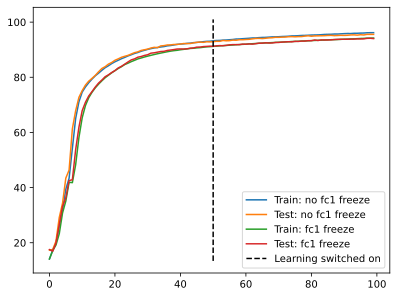

In [42]:
fig = plt.figure()
plt.plot(trainAcc_no_freeze_fc1,label='Train: no fc1 freeze')
plt.plot(testAcc_no_freeze_fc1,label='Test: no fc1 freeze')
plt.plot(trainAcc_freeze_fc1,label='Train: fc1 freeze')
plt.plot(testAcc_freeze_fc1,label='Test: fc1 freeze')
yminmax = [0.95*np.min([trainAcc_no_freeze_fc1, testAcc_no_freeze_fc1, trainAcc_freeze_fc1, testAcc_freeze_fc1]),
           1.05*np.max([trainAcc_no_freeze_fc1, testAcc_no_freeze_fc1, trainAcc_freeze_fc1, testAcc_freeze_fc1])]
plt.plot([len(trainAcc_no_freeze_fc1)/2, len(trainAcc_freeze_fc1)/2], yminmax, 'k--',label='Learning switched on')
plt.legend()
plt.show()